# 1. Introduction

# Netflix Data Analysis Project

## Introduction

This project focuses on analyzing Netflix movies and TV shows data using Python. The goal of the analysis is to explore content trends, identify popular genres, analyze country-wise content distribution, and understand how Netflix content has evolved over time.

Using Python libraries such as Pandas, Matplotlib, and Seaborn, exploratory data analysis (EDA) and visualizations were performed to extract meaningful business insights from the dataset.

### Tools & Technologies Used

* Python
* Pandas
* NumPy
* Matplotlib
* Seaborn
* Jupyter Notebook

### Objectives

* Perform data cleaning and preprocessing
* Analyze Movies vs TV Shows distribution
* Identify top content-producing countries
* Explore release year trends
* Analyze content ratings and genres
* Generate insights through visualizations


# 2. Data Loading

### Data Loading

The dataset was loaded into Python using Pandas. Initial exploration was performed to understand the structure, dimensions, and features of the dataset.


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as pl
import seaborn as sns
df = pd.read_csv("netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
df.shape

(8807, 12)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


# 3. Data Cleaning

### Data Cleaning

Data cleaning is an important step in data analysis. Missing values, duplicate records, and inconsistent data were handled to improve data quality before analysis.

In [4]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [5]:
df.drop_duplicates(inplace=True)

In [6]:
df['country'].fillna('Unknown', inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_10672\2372192134.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['country'].fillna('Unknown', inplace=True)


In [7]:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

# 4. Exploratory Data Analysis (EDA)

### Exploratory Data Analysis (EDA)

EDA was performed to identify trends, patterns, and relationships within the Netflix dataset. Various statistical summaries and visualizations were used to better understand the data.

# 5. Visualizations

## A. Movies vs TV Shows

### Movies vs TV Shows Distribution

This analysis compares the number of Movies and TV Shows available on Netflix.

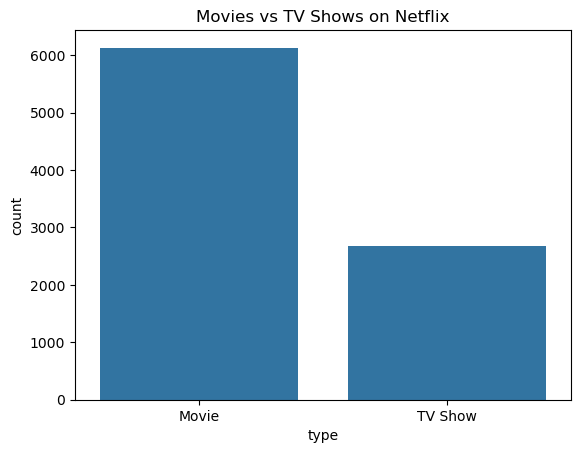

In [8]:
sns.countplot(x='type', data=df)

plt.title("Movies vs TV Shows on Netflix")

plt.show()

## B. Top Countries

### Top Content Producing Countries

This visualization shows the countries producing the highest amount of Netflix content.

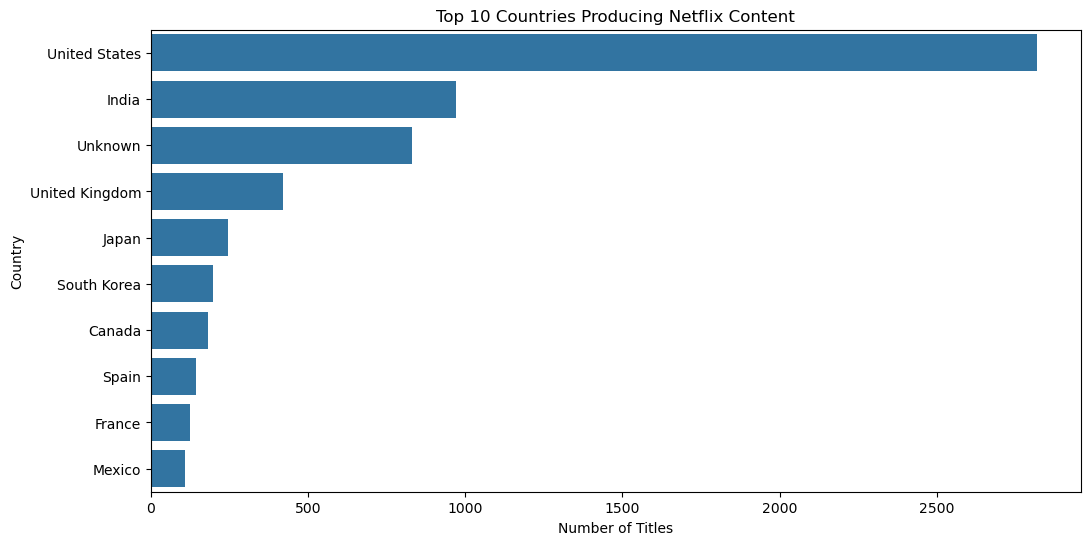

In [9]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 10 Countries Producing Netflix Content")

plt.xlabel("Number of Titles")

plt.ylabel("Country")

plt.show()

### Insight

United States contributes the highest amount of Netflix content, followed by India and the United Kingdom.

## C. Release Year Trend

### Content Release Trend Over Time

This analysis explores how Netflix content production has changed over the years.

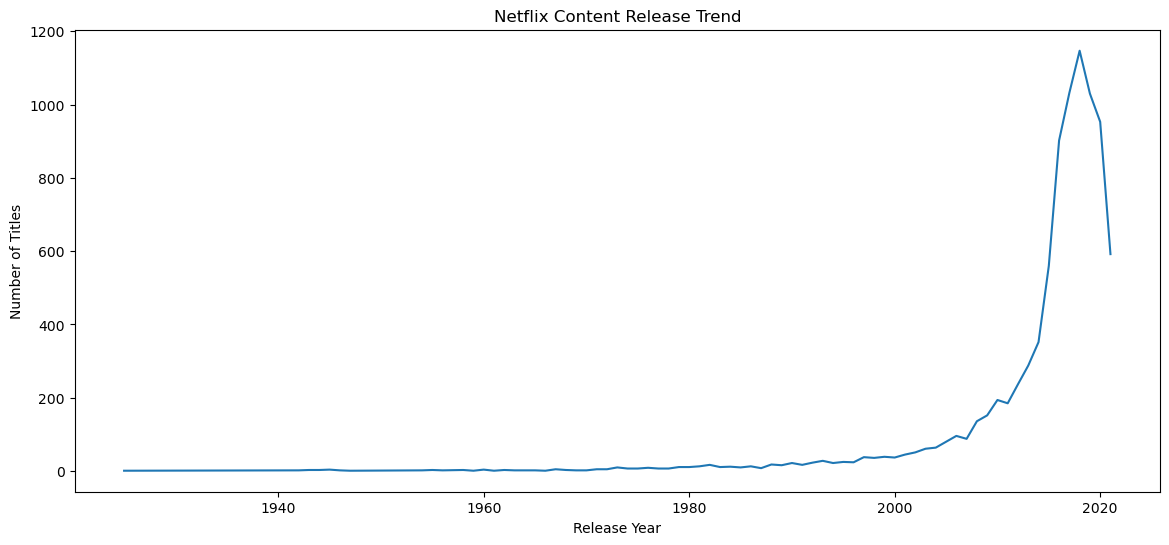

In [10]:
year_data = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(14,6))

plt.plot(year_data.index, year_data.values)

plt.title("Netflix Content Release Trend")

plt.xlabel("Release Year")

plt.ylabel("Number of Titles")

plt.show()

### Insight

Netflix content production increased rapidly after 2015, showing major platform expansion.

## D. Top Genres Analysis

### Most Popular Genres on Netflix

This visualization identifies the most common genres available on Netflix to understand audience preferences and content diversity.

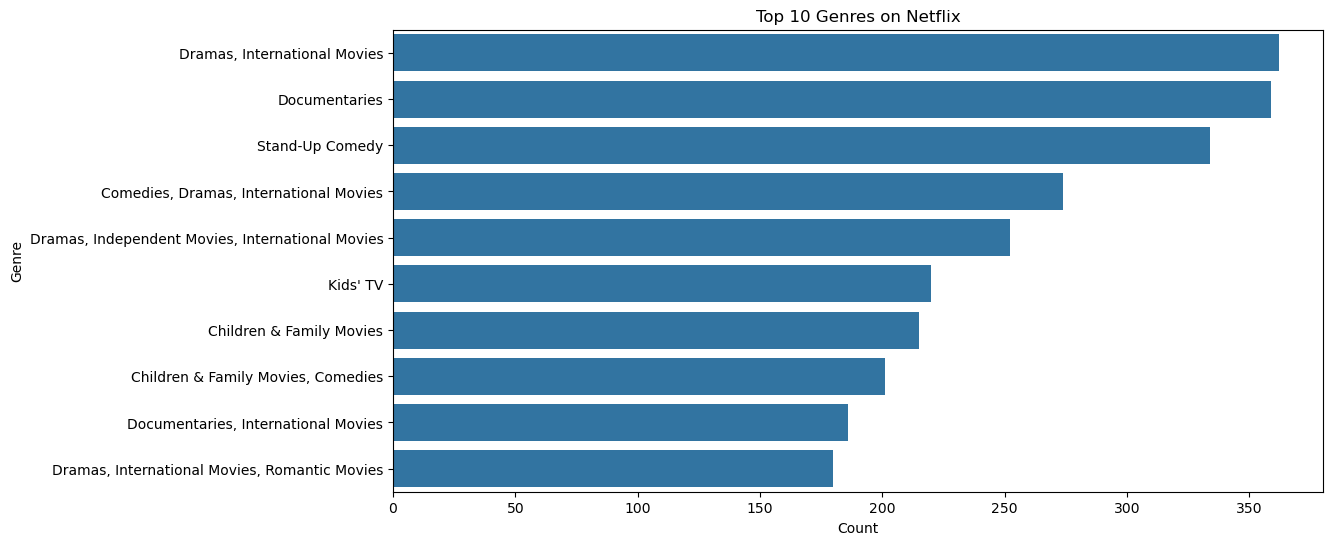

In [11]:
top_genres = df['listed_in'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top 10 Genres on Netflix")

plt.xlabel("Count")

plt.ylabel("Genre")

plt.show()

### Insight

Drama and Comedy are among the most dominant genres available on Netflix.

## E. Ratings Distribution

### Distribution of Content Ratings

This analysis examines the distribution of content ratings available on Netflix. Understanding ratings helps identify the primary audience targeted by the platform.

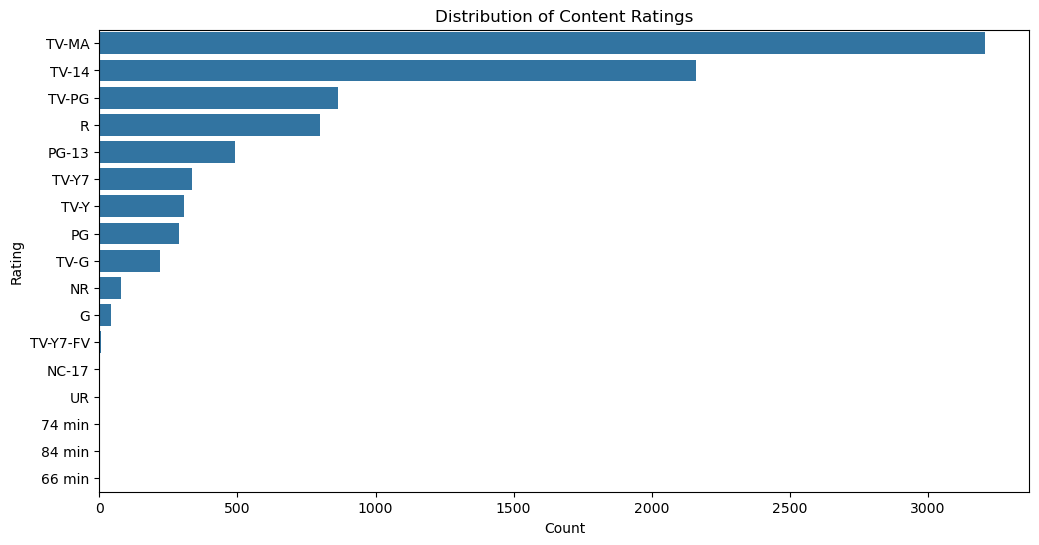

In [12]:
plt.figure(figsize=(12,6))

sns.countplot(
    y='rating',
    data=df,
    order=df['rating'].value_counts().index
)

plt.title("Distribution of Content Ratings")

plt.xlabel("Count")

plt.ylabel("Rating")

plt.show()

### Insight

TV-MA and TV-14 ratings dominate the platform, indicating strong adult and teen-focused content.

## F. Movies Released Each Year

### Movies Released Each Year

This analysis explores yearly movie release trends to understand how Netflix movie content has expanded over time.

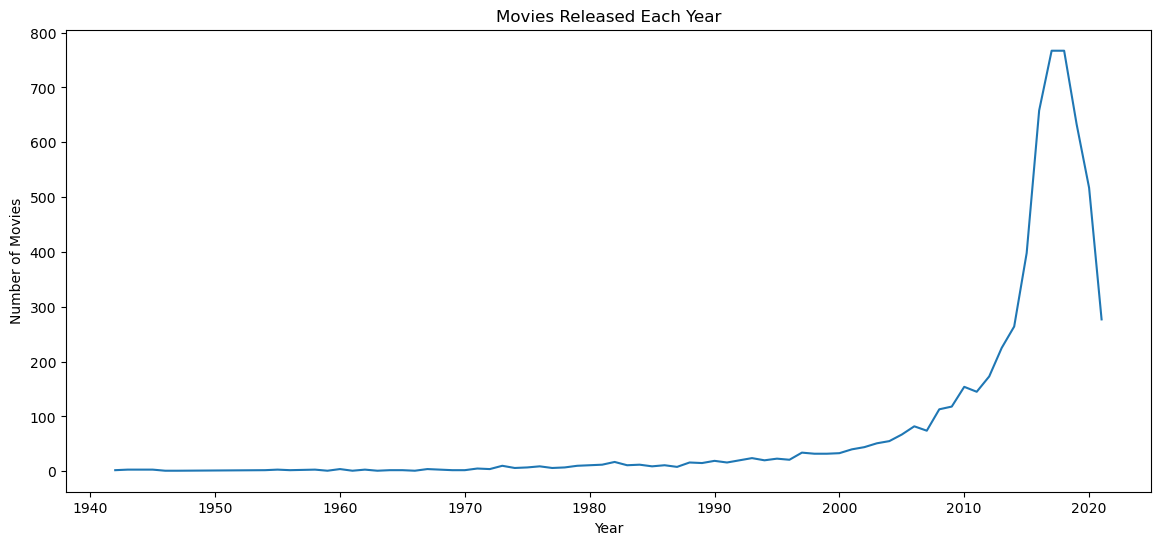

In [13]:
movies = df[df['type'] == 'Movie']

movie_year = movies['release_year'].value_counts().sort_index()

plt.figure(figsize=(14,6))

plt.plot(movie_year.index, movie_year.values)

plt.title("Movies Released Each Year")

plt.xlabel("Year")

plt.ylabel("Number of Movies")

plt.show()

### Insight

Movie releases increased significantly after 2015, showing rapid expansion of Netflix’s global content library.

## G. TV Shows vs Movies Pie Chart

### Movies vs TV Shows Percentage Distribution

This pie chart represents the proportion of Movies and TV Shows available on Netflix. It helps visualize the overall content distribution on the platform.

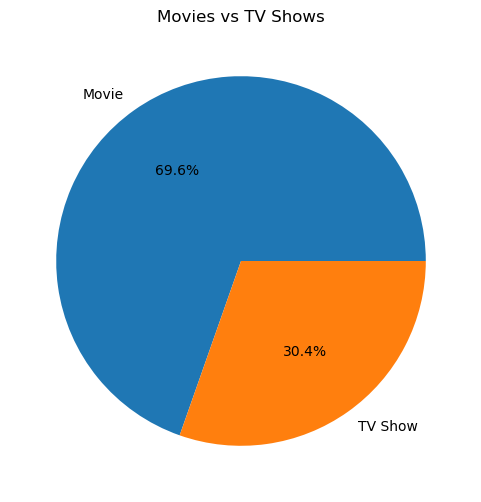

In [14]:
type_counts = df['type'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%'
)

plt.title("Movies vs TV Shows")

plt.show()

### Insight

Movies make up the majority of Netflix content, while TV Shows represent a smaller portion of the platform’s overall library. This indicates Netflix’s stronger focus on movie-based entertainment content.

## H. Top Directors Analysis

### Top Directors on Netflix

This analysis identifies directors with the highest number of titles on Netflix to understand major contributors to the platform’s content library.

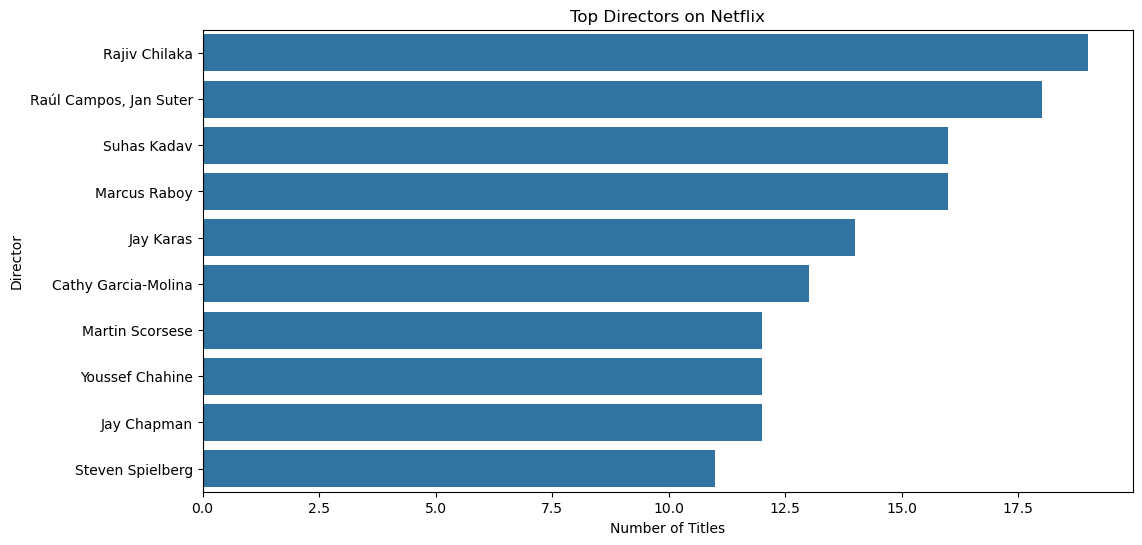

In [15]:
top_directors = df['director'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_directors.values,
    y=top_directors.index
)

plt.title("Top Directors on Netflix")

plt.xlabel("Number of Titles")

plt.ylabel("Director")

plt.show()

### Insight

A small number of directors contribute multiple titles to Netflix, indicating recurring collaborations and strong content partnerships.

## I. Most Common Movie Durations 

### Most Common Movie Durations

This visualization explores the most frequent movie durations available on Netflix to understand standard content length patterns.

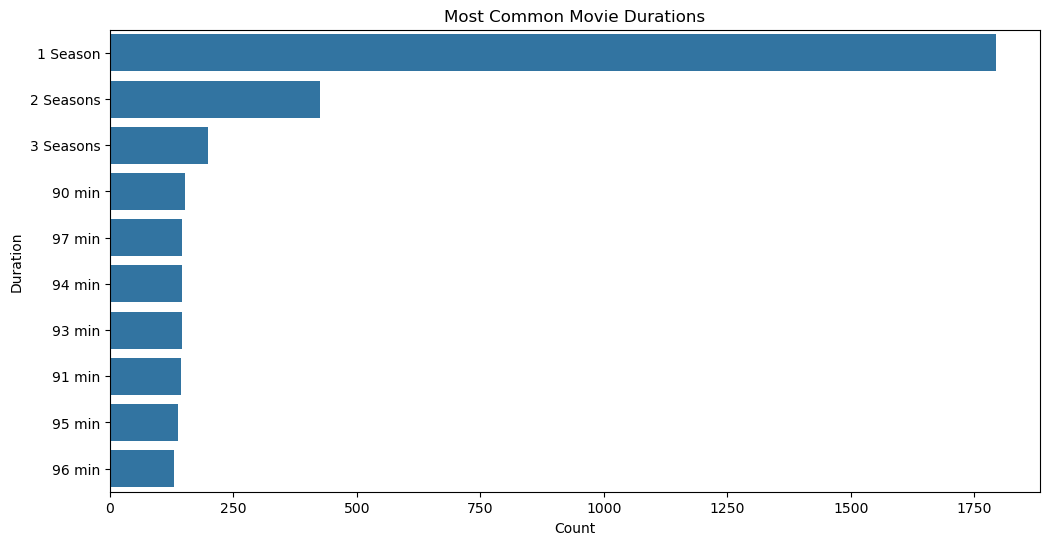

In [17]:
plt.figure(figsize=(12,6))

sns.countplot(
    y='duration',
    data=df,
    order=df['duration'].value_counts().iloc[:10].index
)

plt.title("Most Common Movie Durations")

plt.xlabel("Count")

plt.ylabel("Duration")

plt.show()

### Insight

Most Netflix movies fall within standard feature-length durations, with approximately 90–120 minutes being the most common range.

## J. Correlation Heatmap

### Correlation Heatmap

A correlation heatmap was created to examine relationships between numerical features within the dataset.

In [ ]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

### Insight

The heatmap provides a quick overview of numerical relationships in the dataset and helps identify potential trends or feature dependencies.

# 6. Insights

# Key Insights

- Movies dominate Netflix content compared to TV Shows.
- The United States produces the highest amount of Netflix content.
- Netflix content releases increased significantly after 2015.
- Drama and Comedy are among the most popular genres.
- TV-MA and TV-14 are the most common content ratings.

# 7. Conclusion

# Conclusion

This project analyzed Netflix content trends using Python and data visualization techniques. Through exploratory data analysis, meaningful insights were extracted regarding content distribution, release trends, genres, and country-wise production patterns.

The project demonstrated practical skills in:
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Data Visualization
- Python Programming
- Analytical Thinking

These insights can help understand audience preferences and Netflix content strategies.